# Week 5 — Support Vector Machines

**Integrated Capstone Project: Breast Cancer (two datasets)**

### Notebook purpose
This notebook applies the Week 5 concepts — **support vector machines (SVMs), the kernel trick, and regularization with the `C` parameter** — to the two breast cancer datasets I use throughout my capstone:

1. **Breast Cancer Wisconsin (Diagnostic)** — tumor morphology measurements from images (radius, texture, perimeter, area, smoothness, concavity).
2. **Breast Cancer Coimbra** — clinical, anthropometric, and blood-based biomarkers (age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, MCP-1).

SVMs are classification models, and both outcomes are binary, so they apply directly. In each part I fit linear and kernel SVMs (RBF, plus a polynomial kernel for Coimbra), tune the `C` and kernel parameters, and compare results. I do not merge the datasets, because they contain different patients and different variables; I analyze each separately and compare at the end.

### Project question
> To what extent can measurable patient and tumor characteristics help distinguish breast cancer cases from non-cancer cases?

### Targets
- Wisconsin: `1 = malignant`, `0 = benign`
- Coimbra: `1 = breast cancer patient`, `0 = healthy control`

### Roadmap
- **Part 1** — Breast Cancer Wisconsin analysis
- **Part 2** — Breast Cancer Coimbra analysis (also adds a polynomial kernel and a decision-boundary visualization)
- **Part 3** — Comparison and overall Week 5 conclusions
- **References**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## Part 1 — Breast Cancer Wisconsin (Diagnostic)

This dataset is loaded from `sklearn.datasets.load_breast_cancer`. It contains 30 tumor measurements computed from digitized images, with each tumor labeled benign or malignant. Every SVM in this part uses `StandardScaler` inside a pipeline, because SVMs are distance-based and sensitive to feature scale.

### 1.1 Load and prepare the data

The sklearn version of the dataset originally uses `0 = malignant` and `1 = benign`. I switch this so that:

- `diagnosis_malignant = 1` means malignant
- `diagnosis_malignant = 0` means benign

I prefer this setup because malignant diagnosis is the outcome I care most about catching.

In [2]:
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df.columns = df.columns.str.replace(" ", "_")

df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
df["diagnosis_label"] = np.where(df["diagnosis_malignant"] == 1, "Malignant", "Benign")

print("Dataset shape:", df.shape)
print("\nDiagnosis counts:")
print(df["diagnosis_label"].value_counts())
df.head()

Dataset shape: (569, 32)

Diagnosis counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


### 1.2 Features and target

The dataset has 30 tumor measurement features including radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry. The target is whether the tumor is malignant.

In [3]:
target_col = "diagnosis_malignant"
label_col = "diagnosis_label"

feature_cols = [col for col in df.columns if col not in [target_col, label_col]]

X = df[feature_cols]
y = df[target_col]

print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

Number of rows: 569
Number of features: 30


### 1.3 Why feature scaling matters for SVM

Feature scaling is very important for SVMs because SVMs depend on distances between points. If one feature has much larger values than another, it can dominate the distance calculation.

For example, tumor area has much larger numeric values than smoothness. Because of this, every SVM model in this notebook uses `StandardScaler` inside a pipeline.

### 1.4 Train-test split

I split the data into training and testing sets. I use stratification so the benign and malignant proportions stay similar in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (455, 30)
Testing shape: (114, 30)

Training target distribution:
diagnosis_malignant
0    0.626
1    0.374
Name: proportion, dtype: float64

Testing target distribution:
diagnosis_malignant
0    0.632
1    0.368
Name: proportion, dtype: float64


### 1.5 Linear SVM with scaling

I start with a linear SVM. A linear SVM uses a straight boundary in the feature space. `StandardScaler` is applied inside a Pipeline so the scaler is fit only on the training data, which avoids data leakage.

In [5]:
linear_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1.0, random_state=42))
])

linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

print("=== Linear SVM Results ===")
print(classification_report(y_test, y_pred_linear, target_names=["Benign", "Malignant"]))

=== Linear SVM Results ===
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



### 1.6 Regularization with C

The `C` parameter controls regularization in SVM:

- Smaller `C` = stronger regularization, wider margin, more tolerance for mistakes
- Larger `C` = weaker regularization, narrower margin, more focus on classifying the training data correctly

If `C` is too large, the model may overfit. If `C` is too small, the model may underfit. I use `GridSearchCV` with 5-fold cross-validation to find the best value.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

linear_param_grid = {
    "model__C": np.logspace(-3, 3, 13)
}

linear_grid = GridSearchCV(
    estimator=linear_svm,
    param_grid=linear_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)

linear_grid.fit(X_train, y_train)

print("Best Linear SVM C:", linear_grid.best_params_["model__C"])
print("Best cross-validated recall:", round(linear_grid.best_score_, 4))

Best Linear SVM C: 1.0
Best cross-validated recall: 0.9471


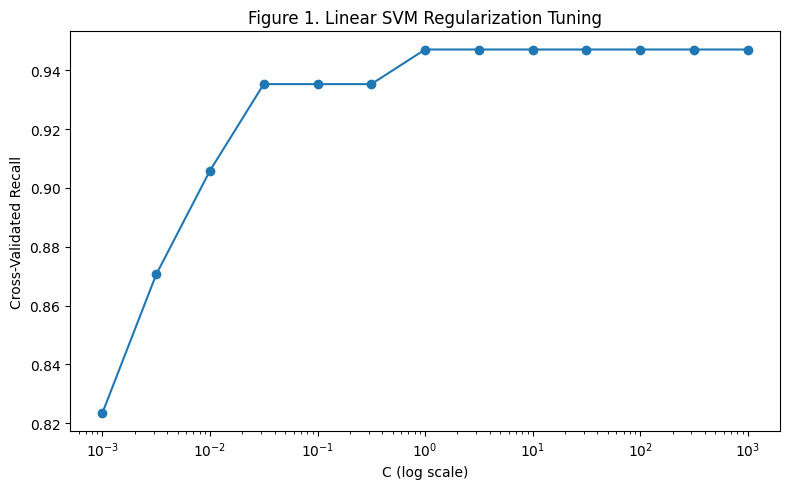

In [7]:
linear_cv_results = pd.DataFrame(linear_grid.cv_results_)
linear_cv_results["C"] = linear_cv_results["param_model__C"].astype(float)

plt.figure(figsize=(8, 5))
plt.semilogx(linear_cv_results["C"], linear_cv_results["mean_test_score"], marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("Cross-Validated Recall")
plt.title("Figure 1. Linear SVM Regularization Tuning")
plt.tight_layout()
plt.show()

### 1.7 The kernel trick

The kernel trick allows an SVM to create nonlinear decision boundaries without manually creating a large number of new variables.

The two kernels I compare here are:

- **Linear kernel:** straight boundary (used in section 6)
- **RBF kernel:** flexible curved boundary

This is useful because benign and malignant tumors may not be separable by a straight line in 30 dimensions.

### 1.8 RBF kernel SVM

The RBF kernel is useful when the boundary between classes may be nonlinear. For the RBF SVM I tune two parameters:

- `C`: regularization strength
- `gamma`: how far the influence of each training point reaches

Smaller `gamma` gives a smoother boundary. Larger `gamma` gives a more complex boundary, which can overfit.

In [8]:
rbf_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", random_state=42))
])

rbf_param_grid = {
    "model__C": np.logspace(-2, 3, 6),
    "model__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

rbf_grid = GridSearchCV(
    estimator=rbf_svm,
    param_grid=rbf_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)

rbf_grid.fit(X_train, y_train)

print("Best RBF parameters:", rbf_grid.best_params_)
print("Best cross-validated recall:", round(rbf_grid.best_score_, 4))

y_pred_rbf = rbf_grid.best_estimator_.predict(X_test)
print("\n=== RBF Kernel SVM Results ===")
print(classification_report(y_test, y_pred_rbf, target_names=["Benign", "Malignant"]))

Best RBF parameters: {'model__C': np.float64(10.0), 'model__gamma': 'scale'}
Best cross-validated recall: 0.9647

=== RBF Kernel SVM Results ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### 1.9 Confusion matrix comparison

I compare the tuned linear SVM and the RBF kernel SVM using confusion matrices on the test set. The confusion matrix shows:

- **True Negative:** benign correctly predicted as benign
- **False Positive:** benign predicted as malignant
- **False Negative:** malignant predicted as benign
- **True Positive:** malignant correctly predicted as malignant

In a healthcare setting, false negatives are the most costly — a missed malignant tumor could delay treatment.

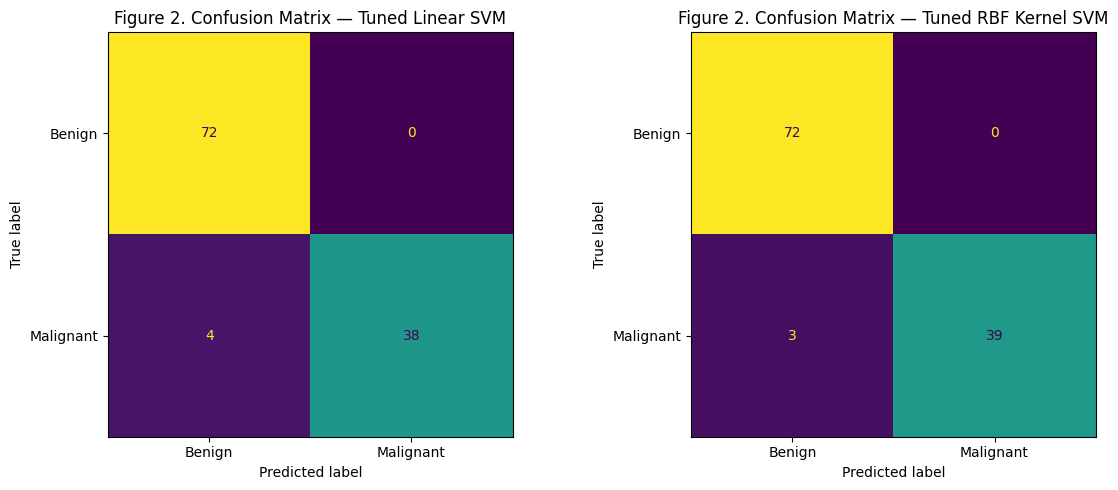

Tuned Linear SVM accuracy: 0.9649
Tuned RBF Kernel SVM accuracy: 0.9737


In [9]:
y_pred_tuned_linear = linear_grid.best_estimator_.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_tuned_linear, y_pred_rbf],
    ["Tuned Linear SVM", "Tuned RBF Kernel SVM"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Figure 2. Confusion Matrix — {title}")

plt.tight_layout()
plt.show()

print("Tuned Linear SVM accuracy:", round(accuracy_score(y_test, y_pred_tuned_linear), 4))
print("Tuned RBF Kernel SVM accuracy:", round(accuracy_score(y_test, y_pred_rbf), 4))

### 1.10 Part 1 summary: Wisconsin

#### Support vector machines

SVMs are a strong fit for this project because the outcome is a binary classification problem. The model tries to separate benign and malignant tumors based on tumor measurements by finding the boundary that best divides the two classes.

#### Feature scaling

Feature scaling was very important for SVMs. Since SVMs depend on distances between points, the features need to be on a similar scale. Without scaling, features with large values like tumor area would dominate the model. Using `StandardScaler` inside a Pipeline ensured the scaler was fit only on the training data, avoiding data leakage.

#### The kernel trick

The linear SVM tests whether the data can be separated with a mostly straight boundary, which serves as a baseline. The RBF kernel uses the kernel trick to create more flexible curved boundaries. This matters because the relationship between tumor features and diagnosis may not be perfectly linear in 30 dimensions. Comparing the two kernels helped me see whether nonlinear boundaries improved classification on this dataset.

#### Regularization with C

The `C` parameter controls regularization in SVMs. A smaller `C` gives stronger regularization and allows more mistakes during training, while a larger `C` tries harder to classify training points correctly but can overfit. I used `GridSearchCV` with 5-fold stratified cross-validation to find the best value of `C` for the linear SVM, and tuned both `C` and `gamma` for the RBF SVM. Tuning these values helped balance underfitting and overfitting.

#### Overall conclusion

Both the tuned linear SVM and the tuned RBF kernel SVM performed well on the breast cancer dataset, with high accuracy and strong recall for malignant cases. This supports my capstone project's central question: measurable tumor characteristics can effectively distinguish between benign and malignant tumors. For this dataset, the linear and RBF kernels produced similar results, which suggests the classes are largely separable, though nonlinear boundaries offer some additional flexibility worth exploring further.

## Part 2 — Breast Cancer Coimbra

The second dataset is the **Breast Cancer Coimbra** dataset. It is also about breast cancer, but it uses a different kind of healthcare information than Wisconsin. Instead of tumor image measurements, it uses clinical and blood-based predictors such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1. The outcome is binary (`1 = breast cancer patient`, `0 = healthy control`), so SVMs apply here just as they do for Wisconsin.

I do not merge the two datasets, because they do not share the same patients or the same variables. I run the same Week 5 methods on each dataset separately and compare them in Part 3. This part goes a bit further than Part 1: it adds a polynomial kernel and a two-feature decision-boundary visualization to make the kernel trick easier to see. Coimbra is also much smaller (116 rows, 9 predictors), so cross-validation matters more here.

**Setup — repeated imports.** The imports are repeated below so this part can be run on its own, even if the notebook is started from here.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)


### 2.1 Load and prepare the data

The Coimbra dataset target is called `Classification`.

The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

For consistency with the rest of my project, I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls

This makes interpretation easier because the positive class is the group I am most interested in detecting.

In [11]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)

coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra dataset shape:", coimbra_df.shape)
print("\nClass counts:")
print(coimbra_df["diagnosis_group"].value_counts())

print("\nClass percentages:")
print(coimbra_df["diagnosis_group"].value_counts(normalize=True).round(3))

print("\nMissing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra dataset shape: (116, 12)

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Class percentages:
diagnosis_group
Patient            0.552
Healthy Control    0.448
Name: proportion, dtype: float64

Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


### 2.2 Features and target

The Coimbra dataset has 9 predictors. These are clinical and blood-based markers rather than tumor image measurements.

Because this dataset is much smaller than Wisconsin, I expect model performance to be more sensitive to the train-test split. This is why cross-validation matters a lot in this section.

In [12]:
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_coimbra = coimbra_df[coimbra_features]
y_coimbra = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("\nNumber of rows:", X_coimbra.shape[0])
print("Number of features:", X_coimbra.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']

Number of rows: 116
Number of features: 9


### 2.3 Exploratory analysis

Before running the SVM models, I want to look at how the predictors differ between patients and healthy controls. This helps connect the model back to the data instead of just running SVM by default.

In [13]:
coimbra_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_group_means["difference_patient_minus_control"] = (
    coimbra_group_means["Patient"] - coimbra_group_means["Healthy Control"]
)

coimbra_group_means.sort_values("difference_patient_minus_control")


diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


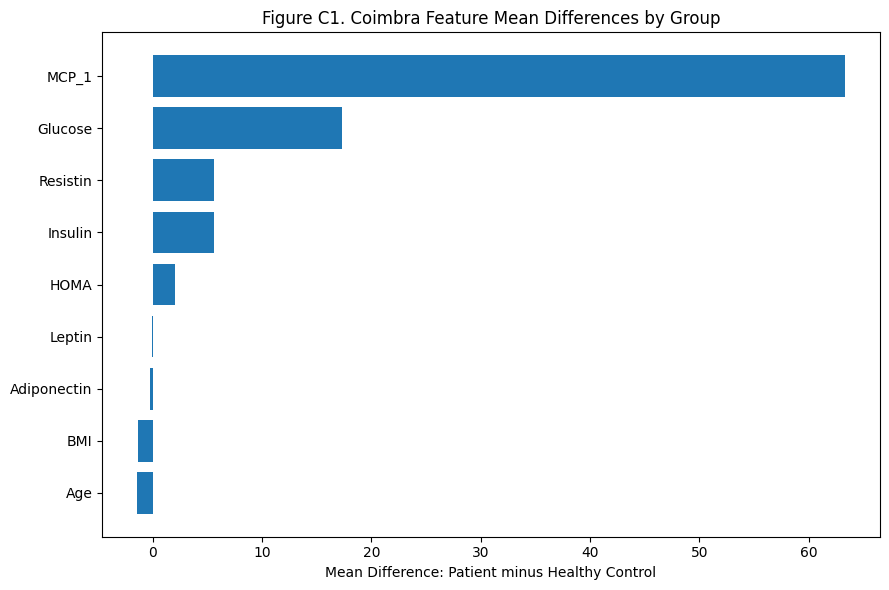

In [14]:
# Figure C1: Coimbra feature mean differences
plot_df = coimbra_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure C1. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()


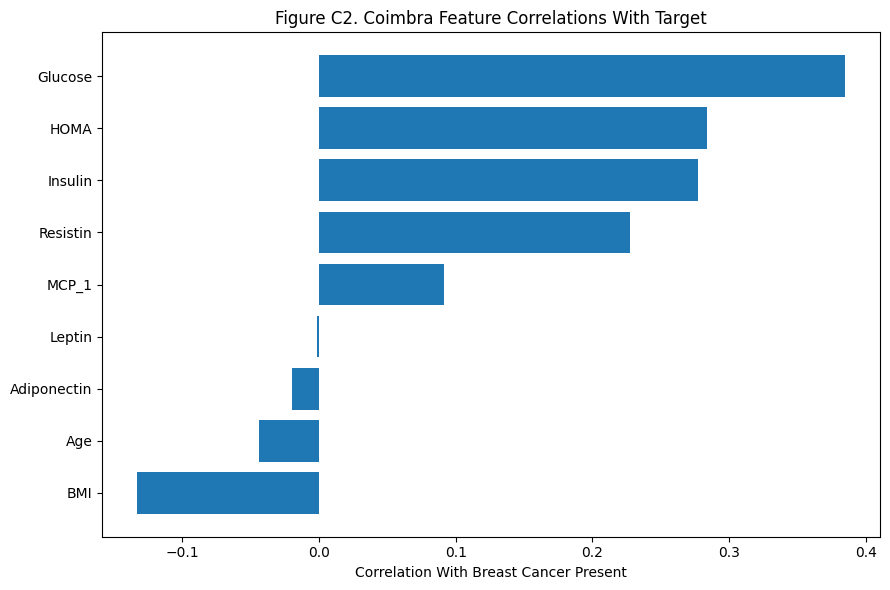

,feature,correlation_with_breast_cancer_present
0,BMI,-0.132586
1,Age,-0.043555
2,Adiponectin,-0.019490
3,Leptin,-0.001078
4,MCP_1,0.091381
5,Resistin,0.227310
6,Insulin,0.276804
7,HOMA,0.284012
8,Glucose,0.384315


In [15]:
# Figure C2: Coimbra feature correlations with breast cancer status
coimbra_corr_with_target = coimbra_df[coimbra_features + [coimbra_target]].corr()[coimbra_target].drop(coimbra_target)
coimbra_corr_sorted = coimbra_corr_with_target.sort_values()

plt.figure(figsize=(9, 6))
plt.barh(coimbra_corr_sorted.index, coimbra_corr_sorted.values)
plt.xlabel("Correlation With Breast Cancer Present")
plt.title("Figure C2. Coimbra Feature Correlations With Target")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": coimbra_corr_sorted.index,
    "correlation_with_breast_cancer_present": coimbra_corr_sorted.values
})


#### Coimbra EDA note

The Coimbra dataset is different from Wisconsin because the predictors are more indirect. Wisconsin uses tumor measurements, while Coimbra uses clinical and blood-based markers. Because of this, I expect Coimbra to be harder to classify than Wisconsin.

However, SVMs may still work well because they can create flexible decision boundaries, especially with kernels like RBF and polynomial.

### 2.4 Feature scaling check

Feature scaling is very important for SVMs because SVMs depend on distances between points. If one feature has much larger values than another, it can dominate the distance calculation.

Coimbra features are on very different scales, so I use `StandardScaler` for the main SVM models.

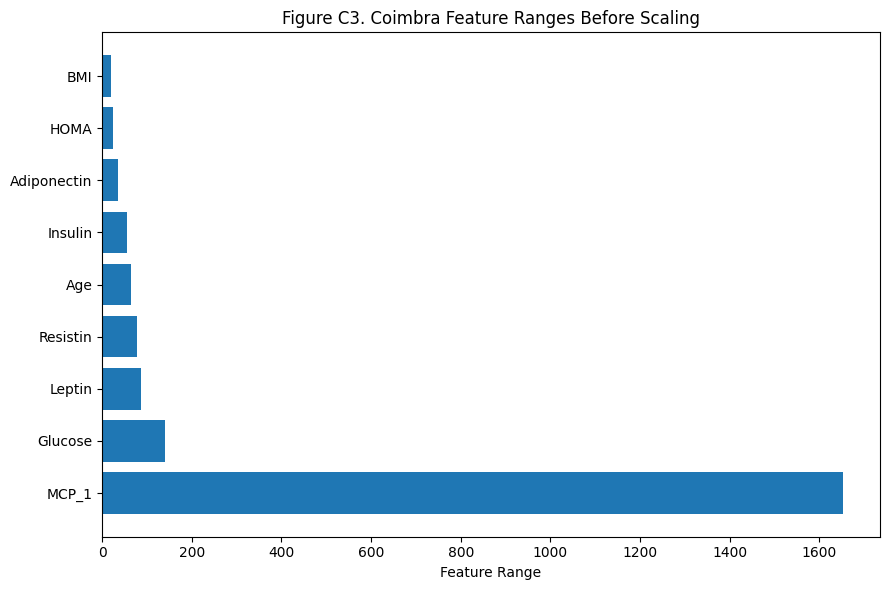

,min,max,mean,std,range
MCP_1,45.843000,1698.440000,534.647000,345.912663,1652.597000
Glucose,60.000000,201.000000,97.793103,22.525162,141.000000
Leptin,4.311000,90.280000,26.615080,19.183294,85.969000
Resistin,3.210000,82.100000,14.725966,12.390646,78.890000
Age,24.000000,89.000000,57.301724,16.112766,65.000000
Insulin,2.432000,58.460000,10.012086,10.067768,56.028000
Adiponectin,1.656020,38.040000,10.180874,6.843341,36.383980
HOMA,0.467409,25.050342,2.694988,3.642043,24.582933
BMI,18.370000,38.578759,27.582111,5.020136,20.208759


In [16]:
scale_summary_c = X_coimbra.agg(["min", "max", "mean", "std"]).T
scale_summary_c["range"] = scale_summary_c["max"] - scale_summary_c["min"]
scale_summary_c = scale_summary_c.sort_values("range", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(scale_summary_c.index, scale_summary_c["range"])
plt.xlabel("Feature Range")
plt.title("Figure C3. Coimbra Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

scale_summary_c[["min", "max", "mean", "std", "range"]]


### 2.5 Train-test split

I use a stratified train-test split so the training and test sets have similar proportions of breast cancer patients and healthy controls.

In [17]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_coimbra,
    y_coimbra,
    test_size=0.20,
    random_state=42,
    stratify=y_coimbra
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)

Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64

Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


### 2.6 SVM evaluation function

The main metrics I use are:

- Accuracy
- Precision for breast cancer patients
- Recall for breast cancer patients
- F1-score
- ROC-AUC

I focus heavily on recall because, in a healthcare setting, missing a breast cancer patient would be a serious concern.

In [18]:
def evaluate_svm_model_c(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_score = model.decision_function(X_train)
    test_score = model.decision_function(X_test)

    results = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_patient": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "test_recall_patient": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_patient": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_score)
    }

    return results, train_pred, test_pred, train_score, test_score


### 2.7 Linear SVM without scaling

I first run a linear SVM without scaling as a comparison point. I do not expect this to be the best model because SVMs usually need scaling.

In [19]:
coimbra_linear_no_scaling = Pipeline(steps=[
    ("model", SVC(kernel="linear", C=1.0, random_state=42))
])

coimbra_no_scaling_results, coimbra_no_scaling_train_pred, coimbra_no_scaling_test_pred, coimbra_no_scaling_train_score, coimbra_no_scaling_test_score = evaluate_svm_model_c(
    "Coimbra Linear SVM: No Scaling",
    coimbra_linear_no_scaling,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_no_scaling_results])


,model,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Linear SVM: No Scaling,0.804348,0.708333,0.8,0.615385,0.695652,0.769231


### 2.8 Linear SVM with scaling

Now I use `StandardScaler` before the linear SVM. This is more appropriate because the Coimbra features have different numeric ranges.

In [20]:
coimbra_linear_scaled = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1.0, random_state=42))
])

coimbra_linear_scaled_results, coimbra_linear_train_pred, coimbra_linear_test_pred, coimbra_linear_train_score, coimbra_linear_test_score = evaluate_svm_model_c(
    "Coimbra Linear SVM: Standard Scaled",
    coimbra_linear_scaled,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_no_scaling_results, coimbra_linear_scaled_results])


,model,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Linear SVM: No Scaling,0.804348,0.708333,0.8,0.615385,0.695652,0.769231
1,Coimbra Linear SVM: Standard Scaled,0.815217,0.708333,0.8,0.615385,0.695652,0.762238


### 2.9 Regularization with C

The `C` parameter controls regularization in SVM.

My understanding is:

- Smaller `C` means stronger regularization and more tolerance for mistakes
- Larger `C` means weaker regularization and more effort to classify training points correctly

If `C` is too large, the model may overfit. If it is too small, the model may underfit.

In [21]:
cv_c = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

coimbra_linear_param_grid = {
    "model__C": np.logspace(-3, 3, 13)
}

coimbra_linear_grid = GridSearchCV(
    estimator=coimbra_linear_scaled,
    param_grid=coimbra_linear_param_grid,
    scoring="recall",
    cv=cv_c,
    n_jobs=-1
)

coimbra_linear_grid.fit(X_train_c, y_train_c)

print("Best Coimbra Linear SVM C:", coimbra_linear_grid.best_params_["model__C"])
print("Best cross-validated recall:", coimbra_linear_grid.best_score_)

coimbra_best_linear_results, coimbra_best_linear_train_pred, coimbra_best_linear_test_pred, coimbra_best_linear_train_score, coimbra_best_linear_test_score = evaluate_svm_model_c(
    "Coimbra Tuned Linear SVM",
    coimbra_linear_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_linear_scaled_results, coimbra_best_linear_results])


Best Coimbra Linear SVM C: 0.001
Best cross-validated recall: 1.0


,model,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Linear SVM: Standard Scaled,0.815217,0.708333,0.800000,0.615385,0.695652,0.762238
1,Coimbra Tuned Linear SVM,0.554348,0.541667,0.541667,1.000000,0.702703,0.741259


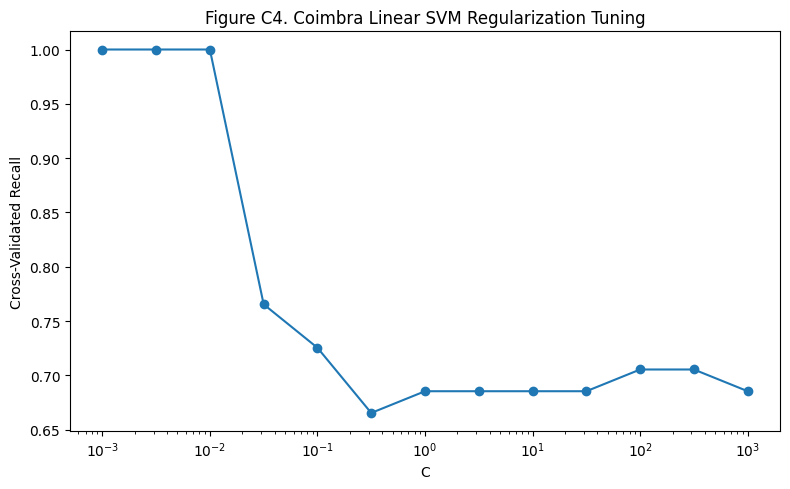

,C,mean_test_score,std_test_score
0,0.001000,1.000000,0.000000
1,0.003162,1.000000,0.000000
2,0.010000,1.000000,0.000000
3,0.031623,0.765455,0.043179
4,0.100000,0.725455,0.074168


In [22]:
# Figure C4: Coimbra linear SVM C tuning
coimbra_linear_cv_results = pd.DataFrame(coimbra_linear_grid.cv_results_)
coimbra_linear_cv_results["C"] = coimbra_linear_cv_results["param_model__C"].astype(float)

plt.figure(figsize=(8, 5))
plt.semilogx(coimbra_linear_cv_results["C"], coimbra_linear_cv_results["mean_test_score"], marker="o")
plt.xlabel("C")
plt.ylabel("Cross-Validated Recall")
plt.title("Figure C4. Coimbra Linear SVM Regularization Tuning")
plt.tight_layout()
plt.show()

coimbra_linear_cv_results[["C", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False).head()


### 2.10 RBF kernel SVM

The RBF kernel allows the model to create a nonlinear decision boundary.

For RBF SVM, I tune:

- `C`: regularization strength
- `gamma`: how far each training point's influence reaches

A smaller `gamma` creates a smoother boundary. A larger `gamma` creates a more complex boundary, but it can overfit.

In [23]:
coimbra_rbf_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", random_state=42))
])

coimbra_rbf_param_grid = {
    "model__C": np.logspace(-2, 3, 6),
    "model__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

coimbra_rbf_grid = GridSearchCV(
    estimator=coimbra_rbf_svm,
    param_grid=coimbra_rbf_param_grid,
    scoring="recall",
    cv=cv_c,
    n_jobs=-1
)

coimbra_rbf_grid.fit(X_train_c, y_train_c)

print("Best Coimbra RBF parameters:")
print(coimbra_rbf_grid.best_params_)
print("Best cross-validated recall:", coimbra_rbf_grid.best_score_)

coimbra_rbf_results, coimbra_rbf_train_pred, coimbra_rbf_test_pred, coimbra_rbf_train_score, coimbra_rbf_test_score = evaluate_svm_model_c(
    "Coimbra Tuned RBF Kernel SVM",
    coimbra_rbf_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_rbf_results])


Best Coimbra RBF parameters:
{'model__C': np.float64(0.01), 'model__gamma': 'scale'}
Best cross-validated recall: 1.0


,model,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Tuned RBF Kernel SVM,0.554348,0.541667,0.541667,1.0,0.702703,0.769231


### 2.11 Polynomial kernel SVM

The polynomial kernel is another way to model nonlinear boundaries.

For polynomial SVM, I tune:

- `C`: regularization
- `degree`: polynomial degree
- `gamma`: kernel coefficient

In [24]:
coimbra_poly_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="poly", random_state=42))
])

coimbra_poly_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__degree": [2, 3, 4],
    "model__gamma": ["scale", 0.01, 0.1]
}

coimbra_poly_grid = GridSearchCV(
    estimator=coimbra_poly_svm,
    param_grid=coimbra_poly_param_grid,
    scoring="recall",
    cv=cv_c,
    n_jobs=-1
)

coimbra_poly_grid.fit(X_train_c, y_train_c)

print("Best Coimbra Polynomial parameters:")
print(coimbra_poly_grid.best_params_)
print("Best cross-validated recall:", coimbra_poly_grid.best_score_)

coimbra_poly_results, coimbra_poly_train_pred, coimbra_poly_test_pred, coimbra_poly_train_score, coimbra_poly_test_score = evaluate_svm_model_c(
    "Coimbra Tuned Polynomial Kernel SVM",
    coimbra_poly_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_poly_results])


Best Coimbra Polynomial parameters:
{'model__C': 0.01, 'model__degree': 2, 'model__gamma': 'scale'}
Best cross-validated recall: 1.0


,model,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Tuned Polynomial Kernel SVM,0.554348,0.541667,0.541667,1.0,0.702703,0.58042


### 2.12 Model comparison

Now I compare the SVM models on the Coimbra dataset.

In [25]:
coimbra_svm_results_df = pd.DataFrame([
    coimbra_no_scaling_results,
    coimbra_linear_scaled_results,
    coimbra_best_linear_results,
    coimbra_rbf_results,
    coimbra_poly_results
])

coimbra_svm_results_df.sort_values("test_recall_patient", ascending=False)


,model,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
2,Coimbra Tuned Linear SVM,0.554348,0.541667,0.541667,1.000000,0.702703,0.741259
4,Coimbra Tuned Polynomial Kernel SVM,0.554348,0.541667,0.541667,1.000000,0.702703,0.580420
3,Coimbra Tuned RBF Kernel SVM,0.554348,0.541667,0.541667,1.000000,0.702703,0.769231
0,Coimbra Linear SVM: No Scaling,0.804348,0.708333,0.800000,0.615385,0.695652,0.769231
1,Coimbra Linear SVM: Standard Scaled,0.815217,0.708333,0.800000,0.615385,0.695652,0.762238


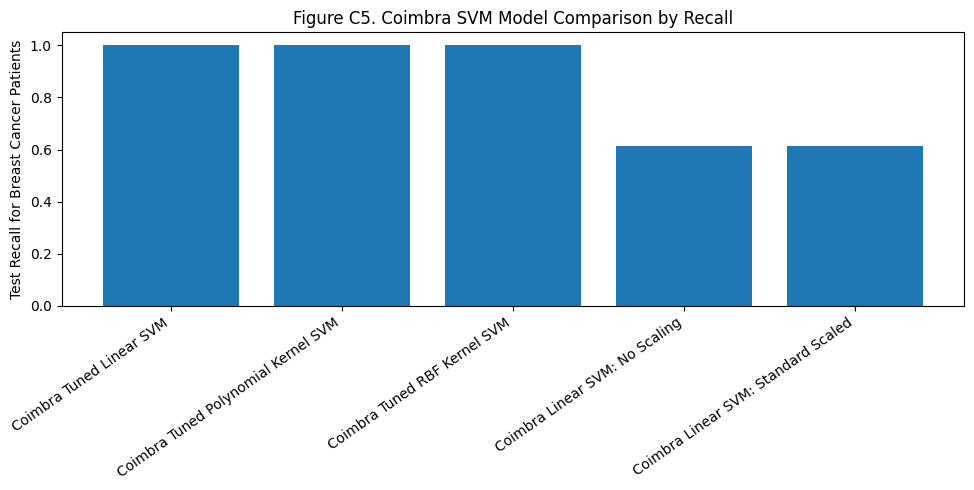

In [26]:
# Figure C5: Coimbra model comparison by recall
plot_df = coimbra_svm_results_df.sort_values("test_recall_patient", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["test_recall_patient"])
plt.ylabel("Test Recall for Breast Cancer Patients")
plt.title("Figure C5. Coimbra SVM Model Comparison by Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


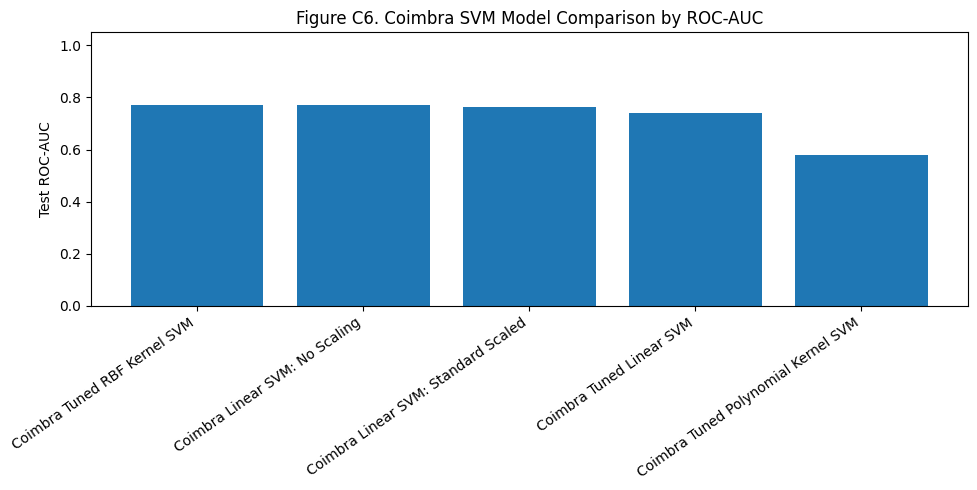

In [27]:
# Figure C6: Coimbra model comparison by ROC-AUC
plot_df = coimbra_svm_results_df.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Figure C6. Coimbra SVM Model Comparison by ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


#### Model comparison interpretation

This comparison helps me see whether the kernel trick helped for Coimbra. If the RBF or polynomial SVM performs better than the linear SVM, that suggests a nonlinear boundary may be useful.

If the linear SVM performs similarly, that suggests the Coimbra classes may be separated about as well using a simpler linear boundary.

### 2.13 Cross-validation comparison

Since the Coimbra dataset is small, cross-validation is very important. A single train-test split can be unstable, so cross-validation gives a more reliable comparison.

In [28]:
coimbra_models_for_cv = {
    "Coimbra Tuned Linear SVM": coimbra_linear_grid.best_estimator_,
    "Coimbra Tuned RBF Kernel SVM": coimbra_rbf_grid.best_estimator_,
    "Coimbra Tuned Polynomial Kernel SVM": coimbra_poly_grid.best_estimator_
}

coimbra_cv_summary = []

for name, model in coimbra_models_for_cv.items():
    recall_scores = cross_val_score(model, X_coimbra, y_coimbra, cv=cv_c, scoring="recall")
    auc_scores = cross_val_score(model, X_coimbra, y_coimbra, cv=cv_c, scoring="roc_auc")
    accuracy_scores = cross_val_score(model, X_coimbra, y_coimbra, cv=cv_c, scoring="accuracy")

    coimbra_cv_summary.append({
        "model": name,
        "CV_recall_mean": recall_scores.mean(),
        "CV_recall_std": recall_scores.std(),
        "CV_roc_auc_mean": auc_scores.mean(),
        "CV_roc_auc_std": auc_scores.std(),
        "CV_accuracy_mean": accuracy_scores.mean(),
        "CV_accuracy_std": accuracy_scores.std()
    })

coimbra_cv_summary_df = pd.DataFrame(coimbra_cv_summary).sort_values("CV_recall_mean", ascending=False)
coimbra_cv_summary_df


,model,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std,CV_accuracy_mean,CV_accuracy_std
0,Coimbra Tuned Linear SVM,1.0,0.0,0.770373,0.124501,0.551812,0.017586
1,Coimbra Tuned RBF Kernel SVM,1.0,0.0,0.814056,0.086053,0.551812,0.017586
2,Coimbra Tuned Polynomial Kernel SVM,1.0,0.0,0.748765,0.079351,0.551812,0.017586


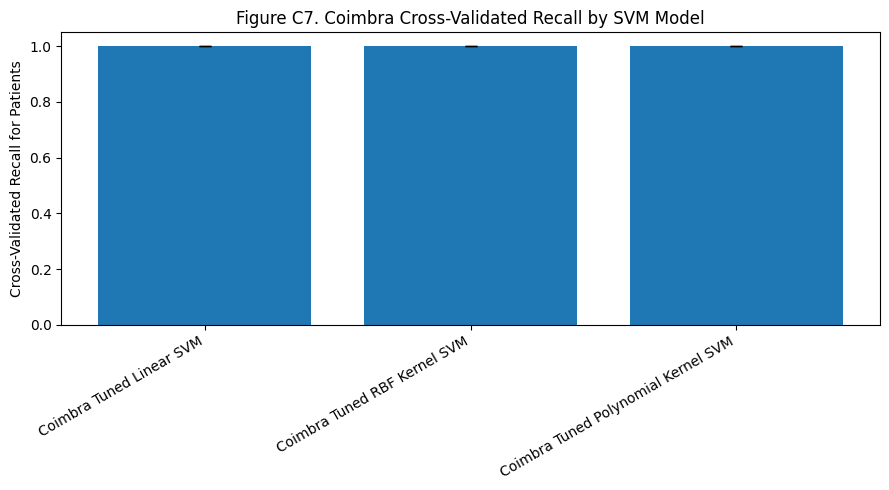

In [29]:
# Figure C7: Coimbra cross-validated recall comparison
plot_df = coimbra_cv_summary_df.sort_values("CV_recall_mean", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["CV_recall_mean"], yerr=plot_df["CV_recall_std"], capsize=4)
plt.ylabel("Cross-Validated Recall for Patients")
plt.title("Figure C7. Coimbra Cross-Validated Recall by SVM Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 2.14 Confusion matrix

I select the best Coimbra SVM based on cross-validated recall and then look at the confusion matrix on the test set.

Best Coimbra SVM model based on cross-validated recall: Coimbra Tuned Linear SVM

Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.00      0.00      0.00        11
        Patient       0.54      1.00      0.70        13

       accuracy                           0.54        24
      macro avg       0.27      0.50      0.35        24
   weighted avg       0.29      0.54      0.38        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


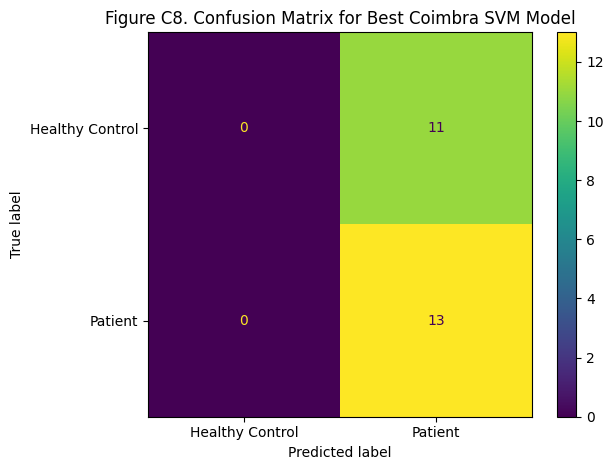

In [30]:
best_coimbra_model_name = coimbra_cv_summary_df.iloc[0]["model"]
best_coimbra_svm_model = coimbra_models_for_cv[best_coimbra_model_name]

best_coimbra_svm_model.fit(X_train_c, y_train_c)
best_coimbra_test_pred = best_coimbra_svm_model.predict(X_test_c)
best_coimbra_test_score = best_coimbra_svm_model.decision_function(X_test_c)

print("Best Coimbra SVM model based on cross-validated recall:", best_coimbra_model_name)
print("\nClassification report:")
print(classification_report(y_test_c, best_coimbra_test_pred, target_names=["Healthy Control", "Patient"]))

cm_c = confusion_matrix(y_test_c, best_coimbra_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_c,
    display_labels=["Healthy Control", "Patient"]
)

disp.plot()
plt.title("Figure C8. Confusion Matrix for Best Coimbra SVM Model")
plt.tight_layout()
plt.show()


### 2.15 ROC curve

The ROC curve shows how well the selected Coimbra SVM separates breast cancer patients from healthy controls.

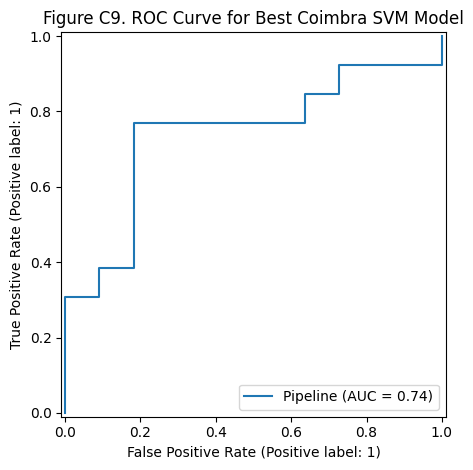

In [31]:
RocCurveDisplay.from_estimator(
    best_coimbra_svm_model,
    X_test_c,
    y_test_c
)

plt.title("Figure C9. ROC Curve for Best Coimbra SVM Model")
plt.tight_layout()
plt.show()


### 2.16 Visualizing the kernel idea with two features

For learning purposes, I make a simple two-feature visualization using `Glucose` and `Resistin`.

This is not the final model. The main models use all features. This plot is just to help me understand how a linear boundary and an RBF boundary can look different.

In [32]:
X_two_c = coimbra_df[["Glucose", "Resistin"]]
y_two_c = coimbra_df["breast_cancer_present"]

X_two_train_c, X_two_test_c, y_two_train_c, y_two_test_c = train_test_split(
    X_two_c,
    y_two_c,
    test_size=0.20,
    random_state=42,
    stratify=y_two_c
)

coimbra_linear_two = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1.0, random_state=42))
])

coimbra_rbf_two = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

coimbra_linear_two.fit(X_two_train_c, y_two_train_c)
coimbra_rbf_two.fit(X_two_train_c, y_two_train_c)

print("Two-feature Coimbra linear SVM test accuracy:", accuracy_score(y_two_test_c, coimbra_linear_two.predict(X_two_test_c)))
print("Two-feature Coimbra RBF SVM test accuracy:", accuracy_score(y_two_test_c, coimbra_rbf_two.predict(X_two_test_c)))


Two-feature Coimbra linear SVM test accuracy: 0.5416666666666666
Two-feature Coimbra RBF SVM test accuracy: 0.5833333333333334


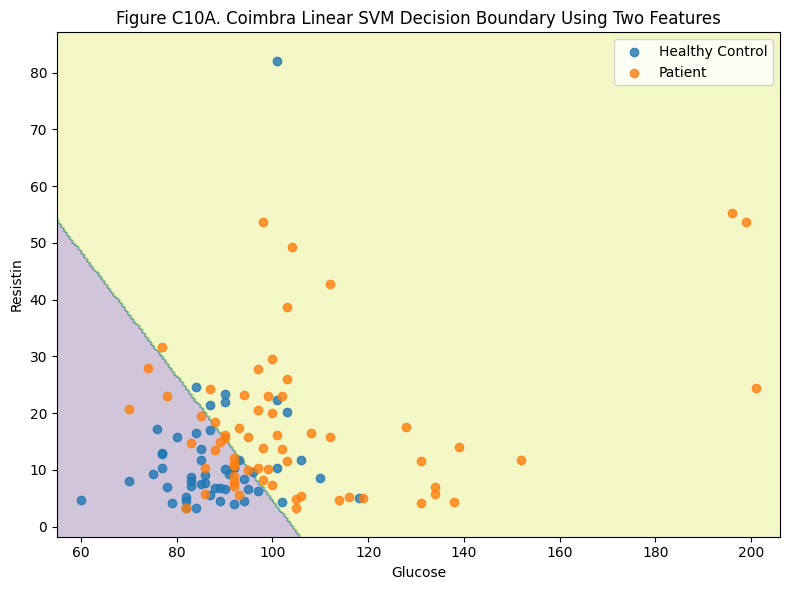

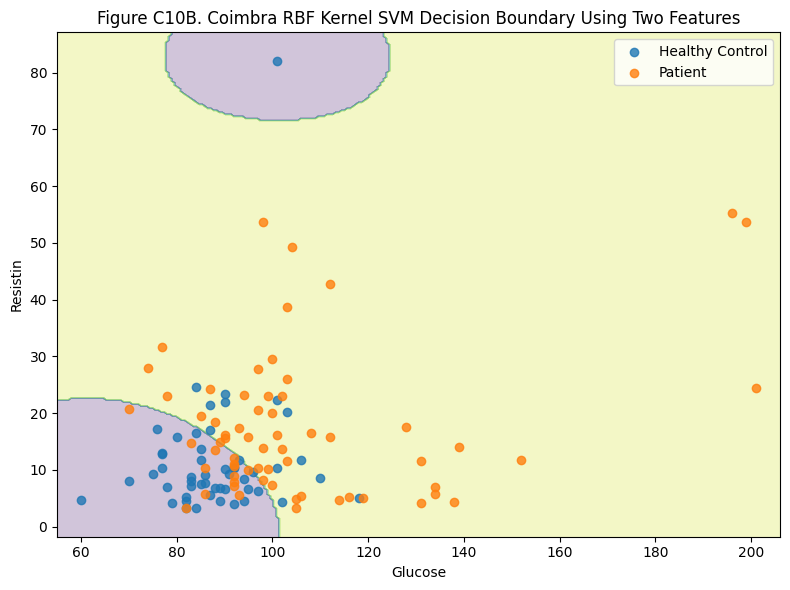

In [33]:
def plot_decision_boundary_c(model, X_data, y_data, title):
    x_min, x_max = X_data.iloc[:, 0].min() - 5, X_data.iloc[:, 0].max() + 5
    y_min, y_max = X_data.iloc[:, 1].min() - 5, X_data.iloc[:, 1].max() + 5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid_points = pd.DataFrame({
        X_data.columns[0]: xx.ravel(),
        X_data.columns[1]: yy.ravel()
    })

    Z = model.predict(grid_points).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)

    for class_value, label in [(0, "Healthy Control"), (1, "Patient")]:
        plt.scatter(
            X_data.iloc[y_data.values == class_value, 0],
            X_data.iloc[y_data.values == class_value, 1],
            label=label,
            alpha=0.8
        )

    plt.xlabel(X_data.columns[0])
    plt.ylabel(X_data.columns[1])
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_boundary_c(
    coimbra_linear_two,
    X_two_c,
    y_two_c,
    "Figure C10A. Coimbra Linear SVM Decision Boundary Using Two Features"
)

plot_decision_boundary_c(
    coimbra_rbf_two,
    X_two_c,
    y_two_c,
    "Figure C10B. Coimbra RBF Kernel SVM Decision Boundary Using Two Features"
)


#### Kernel visualization interpretation

The two-feature plots help me understand the kernel trick. The linear SVM creates a straighter boundary, while the RBF SVM can create a more curved boundary. Since Coimbra uses clinical biomarkers, the relationships may not be as visually separated as the Wisconsin tumor image features.

### 2.17 Results summary for the milestone

This cell prints a short summary using the actual results from the Coimbra section. I can use this later when I write Milestone One.

In [34]:
best_coimbra_test_model = coimbra_svm_results_df.sort_values(
    ["test_recall_patient", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_coimbra_cv_model = coimbra_cv_summary_df.sort_values(
    ["CV_recall_mean", "CV_roc_auc_mean"],
    ascending=[False, False]
).iloc[0]

print("Coimbra Week 5 Summary")
print("----------------------")

print("Best Coimbra test-set model by recall and ROC-AUC:")
print(best_coimbra_test_model["model"])
print(f"Test accuracy: {best_coimbra_test_model['test_accuracy']:.4f}")
print(f"Test precision for patients: {best_coimbra_test_model['test_precision_patient']:.4f}")
print(f"Test recall for patients: {best_coimbra_test_model['test_recall_patient']:.4f}")
print(f"Test F1 for patients: {best_coimbra_test_model['test_f1_patient']:.4f}")
print(f"Test ROC-AUC: {best_coimbra_test_model['test_roc_auc']:.4f}")

print("\nBest Coimbra cross-validated model by recall and ROC-AUC:")
print(best_coimbra_cv_model["model"])
print(f"CV recall: {best_coimbra_cv_model['CV_recall_mean']:.4f} ± {best_coimbra_cv_model['CV_recall_std']:.4f}")
print(f"CV ROC-AUC: {best_coimbra_cv_model['CV_roc_auc_mean']:.4f} ± {best_coimbra_cv_model['CV_roc_auc_std']:.4f}")

print("\nBest Coimbra hyperparameters:")
print("Linear SVM:", coimbra_linear_grid.best_params_)
print("RBF SVM:", coimbra_rbf_grid.best_params_)
print("Polynomial SVM:", coimbra_poly_grid.best_params_)


Coimbra Week 5 Summary
----------------------
Best Coimbra test-set model by recall and ROC-AUC:
Coimbra Tuned RBF Kernel SVM
Test accuracy: 0.5417
Test precision for patients: 0.5417
Test recall for patients: 1.0000
Test F1 for patients: 0.7027
Test ROC-AUC: 0.7692

Best Coimbra cross-validated model by recall and ROC-AUC:
Coimbra Tuned RBF Kernel SVM
CV recall: 1.0000 ± 0.0000
CV ROC-AUC: 0.8141 ± 0.0861

Best Coimbra hyperparameters:
Linear SVM: {'model__C': np.float64(0.001)}
RBF SVM: {'model__C': np.float64(0.01), 'model__gamma': 'scale'}
Polynomial SVM: {'model__C': 0.01, 'model__degree': 2, 'model__gamma': 'scale'}


## Part 3 — Comparison and overall conclusions

### 3.1 Comparison: Wisconsin vs. Coimbra

With both datasets analyzed, I can compare SVM performance across two breast cancer datasets.

The **Wisconsin dataset** uses tumor image-based morphology features. Since these features directly describe the tumor, I expect SVM models to separate benign and malignant cases more clearly.

The **Coimbra dataset** uses clinical and blood-based biomarkers. These variables may still help classify patients and healthy controls, but they are more indirect. Because Coimbra is also smaller, the SVM models may be more sensitive to the train-test split and hyperparameter choices.

Feature scaling mattered in both datasets because SVMs rely on distances between observations. The kernel trick also mattered because it allowed me to test whether nonlinear boundaries improved classification. For Wisconsin, nonlinear boundaries may capture complex tumor morphology patterns. For Coimbra, nonlinear kernels may capture relationships among biomarkers such as glucose, insulin, HOMA, and resistin.

### 3.2 Overall Week 5 conclusions

Across the two datasets, I found that SVMs can be applied to both breast cancer datasets, but the interpretation changes based on the type of predictors.

For Wisconsin, the model uses direct tumor measurements, so strong classification performance would make sense. For Coimbra, the model uses clinical and blood-based markers, so the relationship to breast cancer status is less direct. This makes Coimbra useful but also more challenging.

The most important Week 5 concept was that SVM performance depends heavily on scaling, kernel choice, and regularization. The `C` parameter controlled how much the model tolerated mistakes. The RBF and polynomial kernels allowed the model to create nonlinear decision boundaries. Tuning `C`, `gamma`, and `degree` helped prevent overfitting and gave a more fair comparison across models.

To reduce overfitting, I used train-test splits, stratification, scaling inside pipelines, cross-validation, and GridSearchCV. This mattered especially for Coimbra because it is a small dataset.

Overall, adding Coimbra makes the capstone stronger because it lets me compare how SVMs perform on image-based tumor measurements versus clinical biomarker data. This supports the larger project question about how different types of healthcare data can support breast cancer prediction.

## References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Support vector machines*. https://scikit-learn.org/stable/modules/svm.html

Scikit-learn developers. (n.d.). *SVC*. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html